In [1]:
# import os
# os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = "0.5"

import numpy as np
import fmdj
from functools import cmp_to_key
import jax
import jax.numpy as jnp
import custom_jax as cj
import numpy as np


Running cmake --build & --install in /home/jens/repos/custom-jax/build
Running cmake --build & --install in /home/jens/repos/custom-jax/build


# Argsort

In [2]:
i1 = jax.random.randint(jax.random.PRNGKey(0), (64,), 0, 2**20).block_until_ready()

isort1a = cj.tree.old_argsort_cubradix(i1)
isort1b = jnp.argsort(i1)
print(jnp.all(isort1a == isort1b))

True


# Lexsort

In [6]:
i3 = jax.random.randint(jax.random.PRNGKey(0), (8*1024*1024,3), 0, 2**30).block_until_ready()

isorted_i3a = cj.tree.old_i3argsort_cubradix(i3)
isorted_i3b = jnp.lexsort(i3.T[::-1], axis=0)

print(jnp.all(isorted_i3a == isorted_i3b))

%timeit -n 10 cj.tree.old_i3argsort_cubradix.jit(i3).block_until_ready()
%timeit -n 10 jnp.lexsort(i3.T[::-1]).block_until_ready()

True
24 ms ± 799 μs per loop (mean ± std. dev. of 7 runs, 10 loops each)
91.9 ms ± 69.3 μs per loop (mean ± std. dev. of 7 runs, 10 loops each)


# I3 Zsort

In [7]:
def less_msb(x:int, y:int):
    return (x < y) and (x < (x ^ y))

def compare_zorder_int(a, b):
    assert np.all(a >= 0) and np.all(b >= 0), "Inputs must be non-negative"
    assert a.dtype == np.int32
    aint, bint = a.view(np.int32), b.view(np.int32)

    msd = 0
    for d in range(1, len(a)):
        if less_msb(aint[msd] ^ bint[msd], aint[d] ^ bint[d]):
            msd = d

    return -1*(a[msd] < b[msd])  + 1 * (a[msd] > b[msd])

In [8]:
x3 = np.float32(np.random.uniform(-0.5,0.5, (64,3)))
i3, valid = fmdj.octree.pos_to_icoord(x3)
m3 = fmdj.octree.morton_3int32_to_3int32(i3)
i3zsort_jax = fmdj.octree.organize_particles(x3, return_sorted=False)[1]
i3zsort_py = np.array(sorted(range(len(x3)), key=cmp_to_key(lambda i, j: compare_zorder_int(i3[i], i3[j]))))
i3zsort_thrust = cj.tree.old_i3zsort_thrust(i3)
i3zmergesort_ffi = cj.tree.old_i3zsort_cubmerge(i3)

print(jnp.all(i3zsort_jax == i3zsort_py))
print(jnp.all(i3zsort_thrust == i3zsort_py))
print(jnp.all(i3zsort_thrust == i3zmergesort_ffi))

True
True
True


In [10]:
i3 = jax.random.randint(jax.random.PRNGKey(0), (1024*1024,3), 0, 2**29).block_until_ready()
%timeit -n 10 cj.tree.old_i3zsort_cubmerge(i3).block_until_ready()
i3 = jax.random.randint(jax.random.PRNGKey(0), (8*1024*1024,3), 0, 2**29).block_until_ready()
%timeit -n 10 cj.tree.old_i3zsort_cubmerge(i3).block_until_ready()
i3 = jax.random.randint(jax.random.PRNGKey(0), (32*1024*1024,3), 0, 2**29).block_until_ready()
%timeit -n 10 cj.tree.old_i3zsort_cubmerge(i3).block_until_ready()

3.4 ms ± 312 μs per loop (mean ± std. dev. of 7 runs, 10 loops each)
25.8 ms ± 267 μs per loop (mean ± std. dev. of 7 runs, 10 loops each)
106 ms ± 281 μs per loop (mean ± std. dev. of 7 runs, 10 loops each)


# F3 Zsort

In [11]:
def xor_msb(a:np.float32, b:np.float32):
    """returns the most significant bit that differs between binary. repr. of floats"""
    if np.sign(a) != np.sign(b):
        return 128
    
    aint = abs(a).view(np.uint32)
    bint = abs(b).view(np.uint32)
    
    exp_a, exp_b = (aint >> 23)-127, (bint >> 23)-127

    if exp_a == exp_b: # If both floats have the same exponent, we need to compare mantissas
        most_sign_bit = int(aint ^ bint).bit_length()
        return exp_a + (most_sign_bit - 24)
    else: # Otherwise the most significant bit corresponds to the larger exponent
        return np.maximum(exp_a, exp_b)

def compare_zorder_float(a, b):
    assert a.dtype == np.float32

    msd = 0
    for d in range(1,3):
        if xor_msb(a[msd], b[msd]) < xor_msb(a[d], b[d]):
            msd = d

    return -1*(a[msd] < b[msd])  + 1 * (a[msd] > b[msd])

x3s = x3 + 0.5
f3zsort_py = np.array(sorted(range(len(x3)), key=cmp_to_key(lambda i, j: compare_zorder_float(np.float32(x3s[i]), np.float32(x3s[j])))))
f3zsort_thrust = cj.tree.old_f3zsort_thrust(jnp.float32(x3s))
pos_zorder_sort_ffi = cj.tree.pos_zorder_sort(jnp.float32(x3s))[1]

print(jnp.all(f3zsort_py == i3zsort_jax))
print(jnp.all(f3zsort_thrust == i3zsort_jax))
print(jnp.all(pos_zorder_sort_ffi == i3zsort_jax))

True
True
True


# Profile

In [12]:
x3 = jax.random.uniform(jax.random.key(1), (1024*1024,3), jnp.float32, -0.49,0.49)

i3, valid = fmdj.octree.pos_to_icoord(x3)
m,x3sorted, i3zsort_jax = fmdj.octree.organize_particles.jit(x3, return_sorted=True)
i3zsort_thrust = cj.tree.old_i3zsort_thrust.jit(i3)
x3sorted2, f3zsort1_ffi = cj.tree.pos_zorder_sort.jit(jnp.float32(x3+0.5))

# ipos = jnp.floor((x3[...,0:3]+0.5) * 2.0**bits).astype(jnp.int32) + 2**(bits-1) 

print(i3zsort_jax.shape)
print(i3zsort_thrust.shape)
print(f3zsort_thrust.shape)
print(jnp.all(i3zsort_jax == i3zsort_thrust))
print(jnp.all(i3zsort_jax == f3zsort1_ffi))

(1048576,)
(1048576,)
(64,)
True
True


In [17]:
from fmdj.utility import Timer

timer = Timer(print_compile=False, print_warmup=False)

for N in (int(1e4), int(3e4), int(1e5), int(3e5), int(1e6), int(3e6), int(1e7), int(3e7)):
    x3 = jax.random.uniform(jax.random.key(0), (N,3), jnp.float32, -0.5,0.5)
    i3, valid = fmdj.octree.pos_to_icoord(x3)
    m3 = fmdj.octree.morton_3int32_to_3int32(i3)
    x3s = x3 + 0.5

    timer.set_tag(N=N)
    timer.timeit_jit(fmdj.octree.organize_particles.jit, x3, return_sorted=False)
    timer.timeit_jit(cj.tree.old_i3zsort_thrust.jit, i3)
    timer.timeit_jit(cj.tree.old_f3zsort_thrust.jit, x3s)
    timer.timeit_jit(cj.tree.old_argsort_cubradix.jit, i3[...,0])
    timer.timeit_jit(cj.tree.old_i3argsort_cubradix.jit, m3)
    timer.timeit_jit(cj.tree.old_i3zsort_cubmerge.jit, m3)
    timer.timeit_jit(cj.tree.pos_zorder_sort.jit, x3s)

------- Starting new group: {'N': 10000} -------
   0.3 ms for organize_particles_run
   0.5 ms for old_i3zsort_thrust_run
   0.5 ms for old_f3zsort_thrust_run
   0.3 ms for old_argsort_cubradix_run
   0.4 ms for old_i3argsort_cubradix_run
   0.3 ms for old_i3zsort_cubmerge_run
   0.3 ms for pos_zorder_sort_run
------- Starting new group: {'N': 30000} -------
   0.3 ms for organize_particles_run
   0.6 ms for old_i3zsort_thrust_run
   0.6 ms for old_f3zsort_thrust_run
   0.3 ms for old_argsort_cubradix_run
   0.5 ms for old_i3argsort_cubradix_run
   0.3 ms for old_i3zsort_cubmerge_run
   0.4 ms for pos_zorder_sort_run
------- Starting new group: {'N': 100000} -------
   1.1 ms for organize_particles_run
   0.7 ms for old_i3zsort_thrust_run
   0.7 ms for old_f3zsort_thrust_run
   0.3 ms for old_argsort_cubradix_run
   1.1 ms for old_i3argsort_cubradix_run
   0.4 ms for old_i3zsort_cubmerge_run
   0.4 ms for pos_zorder_sort_run
------- Starting new group: {'N': 300000} -------
   1.7 ms 

<Axes: xlabel='N', ylabel='Time (ms)'>

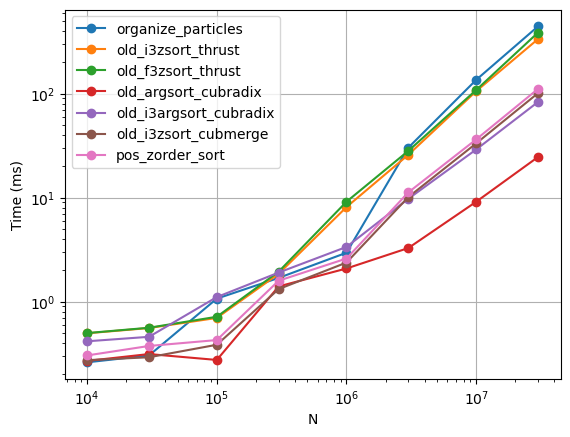

In [18]:
timer.plot_timings("N")